## MA (Moving Average Model)

MA model uses past errors to make predictions.

### Idea:
Current value depends on past prediction errors



### Example:
If yesterday’s prediction had error,
today’s value adjusts using that error



### Key Point:
Uses past errors, not past values

<img src="MA_model_G.png" alt="Time Series info" width="900" height="500" />


In [ ]:
# Install yfinance if you haven't already (uncomment the line below)
# !pip install -q yfinance

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.tsa.arima.model import ARIMA
import plotly.graph_objects as go
import warnings
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Ignore harmless warnings for a cleaner output
warnings.filterwarnings("ignore")

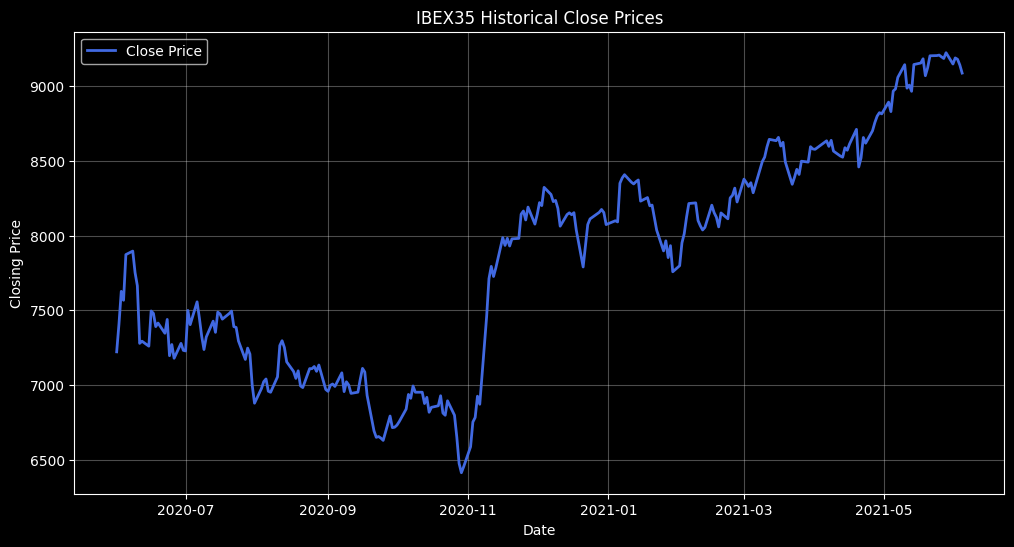

In [5]:
# Fetch historical data for IBEX35 using its ticker symbol
print("Downloading IBEX35 data...")
IBEX = yf.Ticker("^IBEX")

# df = IBEX.history(start="2020-06-01")  # last 6 years data
df = IBEX.history(start="2020-06-01", end="2021-06-05") 

# We only need the 'Close' price for our forecasting
df = df[['Close']].dropna()


# Create the plot
plt.figure(figsize=(12, 6))

# Plot Close Prices
plt.plot(df.index, df['Close'], 
         label='Close Price', 
         color='royalblue', 
         linewidth=2)

# Labels and title
plt.title("IBEX35 Historical Close Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Grid and legend
plt.grid(alpha=0.3)
plt.legend()

# Show the plot
plt.show()


**Raw Data Line Plot (Historical Close Prices):**
   * *What it shows:* The actual stock prices over time. 
   * *What to look for:* Notice how it constantly trends upwards or downwards. This proves the data is **Non-Stationary** and needs differencing.


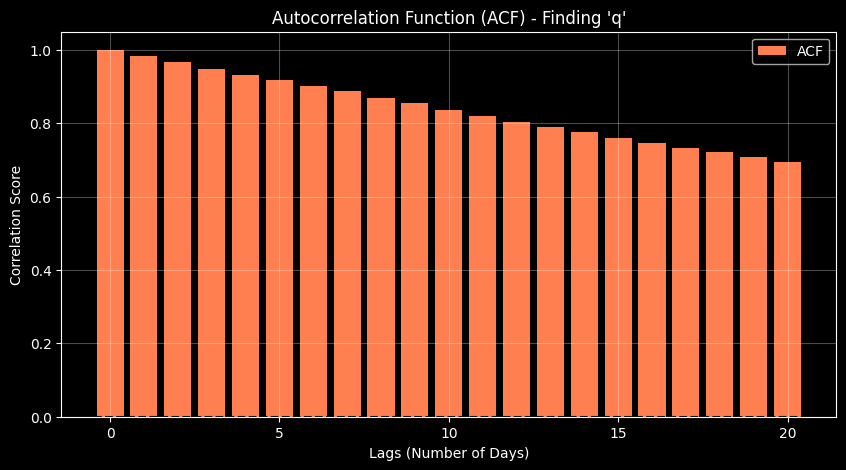

In [6]:
# Calculate the Autocorrelation values for the first 20 lags
# We use the 'Close' column to see how today's price correlates with past days
acf_values = acf(df['Close'], nlags=20)

# Create the plot
plt.figure(figsize=(10, 5))

# Bar chart for ACF values
plt.bar(range(len(acf_values)), acf_values, color='coral', label='ACF')

# Horizontal line at 0
plt.axhline(y=0, color='black', linestyle='dashed')

# Labels and title
plt.title("Autocorrelation Function (ACF) - Finding 'q'")
plt.xlabel("Lags (Number of Days)")
plt.ylabel("Correlation Score")

# Optional grid for readability
plt.grid(alpha=0.3)

# Show legend (optional here since only one series)
plt.legend()

# Show the plot
plt.show()

# OBSERVATION:
# In heavily trending data (like stocks), the ACF decays very slowly. 
# For now, we will set q=10, meaning our model will look at the 
# prediction errors from the last 10 days to adjust today's forecast.


**Autocorrelation Function (ACF) Bar Chart:**
   * *What it shows:* How strongly today's price is connected to past days (lags).
   * *What to look for:* If the bars drop off very slowly, the data has a strong trend. We look for the point where the bars "cut off" or hit the zero line to choose our `q` parameter for the MA model.



In [7]:
# Define the ARIMA model with order (0, 0, 10) to create a pure MA(10) model
MA_model = ARIMA(endog=df['Close'], order=(0, 0, 10))

# Fit the model to our dataset
results = MA_model.fit()

# Print the statistical summary of the trained model
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  261
Model:                ARIMA(0, 0, 10)   Log Likelihood               -1699.770
Date:                Wed, 06 May 2026   AIC                           3423.541
Time:                        18:10:30   BIC                           3466.315
Sample:                             0   HQIC                          3440.735
                                - 261                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       7827.5875    114.644     68.278      0.000    7602.890    8052.285
ma.L1          1.0144      0.095     10.719      0.000       0.829       1.200
ma.L2          1.1281      0.109     10.307      0.0

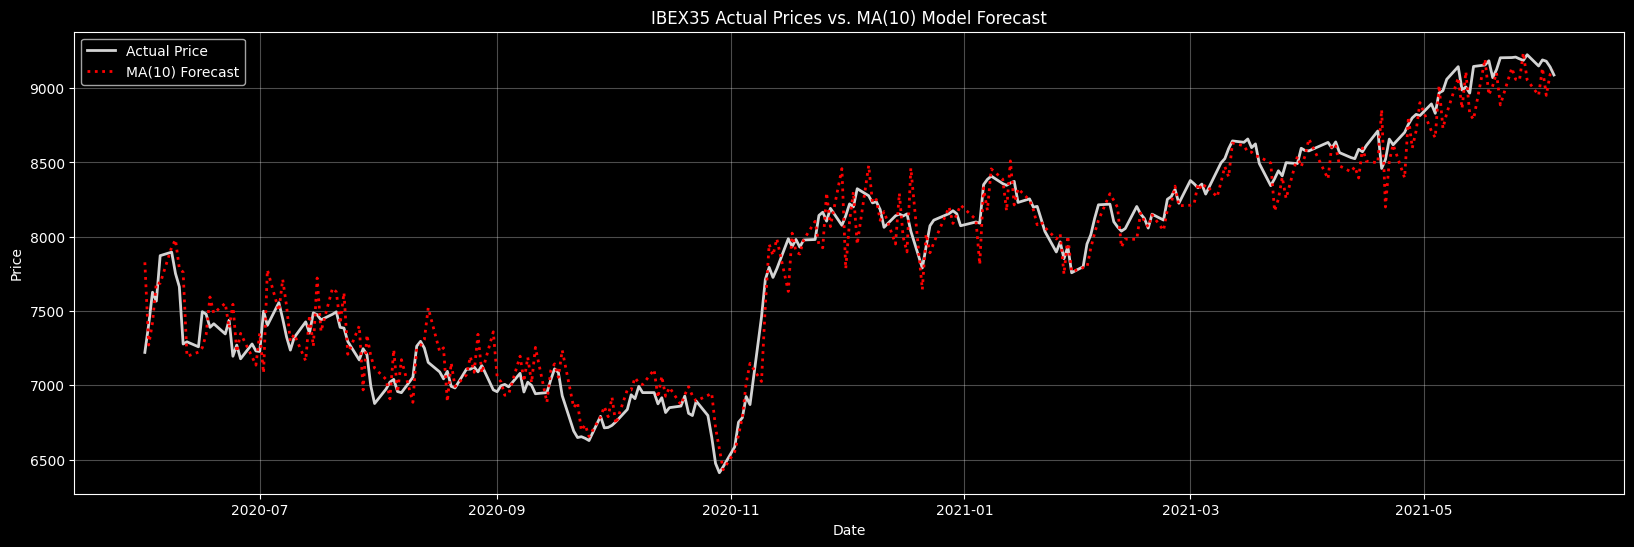

In [8]:
# Generate predictions for the entire dataset timeline
start_date = df.index.min()
end_date = df.index.max()

# Create a new column in our dataframe for the forecasted values
df['forecast'] = results.predict(start=start_date, end=end_date)

# Create the plot
plt.figure(figsize=(20, 6))

# Plot the Actual Close Prices
plt.plot(df.index, df['Close'], 
         label='Actual Price', 
         color='lightgrey', 
         linewidth=2)

# Plot the MA(10) Forecasted Prices
plt.plot(df.index, df['forecast'], 
         label='MA(10) Forecast', 
         color='red', 
         linewidth=2, 
         linestyle='dotted')

# Labels and title
plt.title("IBEX35 Actual Prices vs. MA(10) Model Forecast")
plt.xlabel("Date")
plt.ylabel("Price")

# Legend
plt.legend()

# Grid (optional, but improves readability)
plt.grid(alpha=0.3)

# Show the plot
plt.show()

**Actual vs. Predicted Forecast Plot:**
   * *What it shows:* The ultimate test. The real-world data (grey line) compared against what our MA model predicted (red dotted line).
   * *What to look for:* How closely the red line hugs the grey line. A tighter hug means a lower Mean Squared Error (MSE) and a smarter model!

In [59]:
df

,Close,forecast
Date,,
2020-06-01 00:00:00+02:00,7221.399902,7827.587461
2020-06-02 00:00:00+02:00,7408.100098,7271.098058
2020-06-03 00:00:00+02:00,7626.399902,7421.720856
2020-06-04 00:00:00+02:00,7566.799805,7691.311633
2020-06-05 00:00:00+02:00,7872.600098,7685.858201
...,...,...
2021-05-31 00:00:00+02:00,9148.900391,8951.798194
2021-06-01 00:00:00+02:00,9189.700195,9134.535995
2021-06-02 00:00:00+02:00,9180.700195,8950.943974


## 🎯 End-to-End Summary - Moving Average (MA) Model

### What We Did:
 -> Loaded real stock price data (IBEX35)
 -> Visualized the time series
 -> Used **ACF Plot** to understand autocorrelation
 -> Trained **MA(10)** model using past errors
 -> Generated forecasts and compared with actual values


### Key Takeaways:
- MA model focuses on **correcting past mistakes** (errors).
- It works well when data has **short-term random shocks**.
- Simple but powerful baseline model for time series forecasting.




If you run the MA model on just **1 year of data** (2020-2021), it looks like it works perfectly. But when we trained it on **6 years of LIVE data**, the model completely failed. Why?

To understand this, we need to look at the **P-value (`P>|z|`)** in our model summary.

### What is the P-Value and Why is it Important?
The P-value tells us if a past error is actually useful for predicting the future, or if it is just random garbage.
* **P-value < 0.05 (Good):** The model is confident. This past data point is statistically significant and helps us predict the future.
* **P-value > 0.05 (Bad):** The model is confused. This past data point is just random noise. 

**What happened with the 6-Year Data?**
In a short 1-year window, the stock market had a temporary pattern (due to the 2020 market crash recovery). 
But over 6 long years, stock prices wander randomly. The model realized that looking at the last 10 days of errors over a 6-year period is mathematically useless. The model's confidence collapsed, and the P-values shot up (e.g., 0.898, 0.968).


To fix high P-values and failing models, we use a technique called **Differencing**. 

### What is Differencing?
Machine Learning models hate data that constantly trends upwards or downwards (Non-Stationary data). Differencing fixes this by predicting the **Daily Price Change** instead of the raw price:
* *Formula:* `Today's Price - Yesterday's Price = Daily Change`
This removes the long-term trend and forces the data to fluctuate stably around a flat `0` line. We call this **Stationary Data**.


When we applied Differencing, the data became perfectly stationary. But the P-values **still remained high!** Why? 

Because Differencing exposed the mathematical truth: **Daily stock market changes are pure "Random Noise" (A Random Walk).** The model correctly told us that yesterday's stock market error cannot predict tomorrow's stock market price. 


##  The Real-World Power of MA Models in Manufacturing

We have seen the math and the behavior of the **Moving Average (MA)** model. But how does this actually help a real factory? 

Unlike stock markets (which are driven by random human emotions), manufacturing equipment is governed by physics. Machines have a "mechanical memory." The pressure of a hydraulic pump right now is heavily influenced by the pressure errors from 5, 10, or 15 seconds ago.

Because MA models excel at learning the patterns of past *errors* (shocks) in stable data, they are incredibly powerful tools for **Predictive Maintenance** and **Quality Control**.

Here are the top use cases for MA Models in the Manufacturing Industry:

### 1.  Hydraulic System Monitoring (Shock Detection)
* **The Problem:** Hydraulic presses and pumps experience sudden pressure spikes or drops when valves open and close. 
* **The MA Solution:** An MA model can track these pressure changes. If a pressure drop is just a normal operational "shock," the MA model will have predicted it based on recent errors. But if the actual pressure drops far below the MA prediction, it immediately flags a dangerous leak or a failing seal.

### 2.  Motor Vibration Analysis (Micro-Fault Detection)
* **The Problem:** Industrial motors and conveyor belts vibrate constantly. When a bearing starts to crack, it doesn't fail instantly; it creates tiny, abnormal vibration spikes hidden inside the normal noise.
* **The MA Solution:** Because vibration data is highly stationary, an MA model can perfectly map the "normal" vibration noise. When the model's prediction suddenly deviates from the actual vibration data, it means a micro-fault (like a cracked bearing) has occurred, allowing teams to fix the machine days before it breaks down completely.

### 3.  Oven & Furnace Temperature Control (Thermal Stability)
* **The Problem:** Industrial ovens used for curing metals or baking electronics must maintain a strict, stable temperature. Small fluctuations are normal, but a failing heating element will cause a drift.
* **The MA Solution:** By applying differencing to temperature data, an MA model can monitor the rate of temperature change. It acts as an advanced, intelligent thermostat. Instead of waiting for the oven to get too cold and ruin a batch of products, the MA model detects the abnormal error pattern and alerts the floor manager early.

### 4.  Flow Rate Consistency in Chemical Plants
* **The Problem:** Mixing chemicals requires exact flow rates through pipes. Blockages build up slowly, causing sudden, small changes in the flow.
* **The MA Solution:** The MA model analyzes the flow rate errors. If the flow rate is jumping around more than the model expects based on the last `q` time steps, it signals that a pipe is likely getting clogged, preventing a spoiled chemical batch.



**The Bottom Line:**
The Moving Average model is a mathematically elegant way to say: *"I know how this machine usually behaves when it hits a bump. If it reacts differently this time, something is broken."*

<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>